In [14]:
from langgraph.graph import StateGraph , START,END
from langchain_openai import ChatOpenAI
from dotenv import  load_dotenv
from typing import  TypedDict


In [15]:
load_dotenv()

model = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    temperature=0.3,
)

In [16]:
class llm_state(TypedDict):
    question:str
    answer:str
    


In [ ]:
def llm_model(state:llm_state)->llm_state:
    response=model.invoke(state['question']).content
    state['answer']=response

    return state

    

In [18]:
#define the graph
graph=StateGraph(llm_state)

#define the node
graph.add_node('llm_model',llm_model)

#define the edge
graph.add_edge(START,'llm_model')
graph.add_edge('llm_model',END)

#compile the graph
llm_workflow=graph.compile()

#execute the graph

In [25]:
#execution 

intial_state=initial_state = {
    "question": "What is capital of Nepal?",
}

final_state=llm_workflow.invoke(intial_state)

In [26]:
print(final_state['question'])
print('\n\n')
print(final_state['answer'])

What is capital of Nepal?



The capital of Nepal is **Kathmandu**. It is the country's largest city and serves as its political, cultural, and economic center. Kathmandu is located in the Kathmandu Valley and is known for its rich history, ancient temples, and vibrant street life.


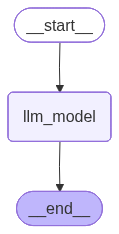

In [24]:
from IPython.display import Image

Image(llm_workflow.get_graph().draw_mermaid_png())